In [ ]:
# ===== Imports =====
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel, Trainer, TrainingArguments
from torch.utils.data import Dataset
import torch.nn as nn

In [ ]:
# ===== Config =====
CSV_FILE = "/kaggle/input/dataresto/yaw-final-data.csv"
TOPICS = ["food", "service", "place", "delivery", "price", "treatment"]
INTENTS = ["appreciation", "complaint", "inquiry", "recommendation", "none"]
INTENT2ID = {intent: i for i, intent in enumerate(INTENTS)}
ID2INTENT = {i: intent for intent, i in INTENT2ID.items()}
MAX_LEN = 128
BATCH_SIZE = 8
EPOCHS = 5
MODEL_NAME = "alger-ia/dziribert"

In [ ]:
# ===== Config =====
CSV_FILE = "/content/yaw-final-data.csv"
TOPICS = ["food", "service", "place", "delivery", "price", "treatment"]
INTENTS = ["appreciation", "complaint", "inquiry", "recommendation", "none"]
INTENT2ID = {intent: i for i, intent in enumerate(INTENTS)}
ID2INTENT = {i: intent for intent, i in INTENT2ID.items()}
MAX_LEN = 128
BATCH_SIZE = 8
EPOCHS = 5
MODEL_NAME = "alger-ia/dziribert"

In [ ]:
# ===== Lire CSV et normaliser =====
df = pd.read_csv(CSV_FILE)
# normalisation
for t in TOPICS:
    df[t] = df[t].fillna("none").str.lower().str.strip()
# supprimer commentaires recommandation partout
df = df[~df.apply(lambda r: all(r[t]=="recommendation" for t in TOPICS), axis=1)]

In [ ]:
from collections import Counter

counts = {topic: Counter() for topic in TOPICS}

for topic in TOPICS:
    for intents_str in df[topic].dropna():
        intents = [i.strip() for i in str(intents_str).split(',') if i.strip()]
        counts[topic].update(intents)

# Convertir en DataFrame
counts_df = pd.DataFrame(counts).fillna(0).astype(int)

# Pourcentages
percent_df = counts_df.div(counts_df.sum(axis=0), axis=1) * 100

print("=== Counts ===")
print(counts_df)
print("\n=== Percentages ===")
print(percent_df.round(2))


=== Counts ===
                 food  service  place  delivery  price  treatment
none            16055    20827  17173     23121  19613      20420
appreciation     4934     2088   3889       220   1154       2647
complaint        2536      960   1116       103   2385        825
inquiry           350       34   1679       474    726         24
recommendation    181       24    126        10     71         35

=== Percentages ===
                 food  service  place  delivery  price  treatment
none            66.74    87.02  71.60     96.63  81.89      85.26
appreciation    20.51     8.72  16.22      0.92   4.82      11.05
complaint       10.54     4.01   4.65      0.43   9.96       3.44
inquiry          1.45     0.14   7.00      1.98   3.03       0.10
recommendation   0.75     0.10   0.53      0.04   0.30       0.15


In [ ]:
from collections import Counter
import pandas as pd
import torch

counts = {topic: Counter() for topic in TOPICS}

for topic in TOPICS:
    for intents_str in df[topic].dropna():
        intents = [i.strip() for i in str(intents_str).split(',') if i.strip()]
        # ❌ exclure none
        intents = [i for i in intents if i.lower() != "none"]
        counts[topic].update(intents)

# DataFrame
counts_df_no_none = pd.DataFrame(counts).fillna(0).astype(int)

percent_df = counts_df_no_none.div(counts_df_no_none.sum(axis=0), axis=1) * 100


print("=== Counts (sans none) ===")
print(counts_df_no_none)
print("\n=== Percentages ===")
print(percent_df.round(2))


=== Counts (sans none) ===
                food  service  place  delivery  price  treatment
appreciation    4934     2088   3889       220   1154       2647
complaint       2536      960   1116       103   2385        825
inquiry          350       34   1679       474    726         24
recommendation   181       24    126        10     71         35

=== Percentages ===
                 food  service  place  delivery  price  treatment
appreciation    61.67    67.22  57.11     27.26  26.61      74.96
complaint       31.70    30.91  16.39     12.76  55.00      23.36
inquiry          4.37     1.09  24.65     58.74  16.74       0.68
recommendation   2.26     0.77   1.85      1.24   1.64       0.99


In [ ]:
to_remove = {
    "food": ["recommendation"],
    "service": ["inquiry", "recommendation"],
    "place": ["recommendation"],
    "delivery": ["recommendation"],
    "price": ["recommendation"],
    "treatment": ["inquiry", "recommendation"],
}


In [ ]:
THRESHOLD = 3.0  # %

to_remove = {}

for topic in percent_df.index:
    low_intents = percent_df.loc[topic][percent_df.loc[topic] < THRESHOLD].index.tolist()
    if low_intents:
        to_remove[topic] = low_intents

print("=== Intents à supprimer par topic ===")
for k, v in to_remove.items():
    print(f"{k}: {v}")


=== Intents à supprimer par topic ===
inquiry: ['service', 'treatment']
recommendation: ['food', 'service', 'place', 'delivery', 'price', 'treatment']


In [ ]:
df_clean = df.copy()

for topic in TOPICS:
    intents_to_remove = to_remove.get(topic, [])
    def filter_intents(x):
        if not isinstance(x, str) or x.strip() == "":
            return "none"
        filtered = [i.strip() for i in x.split(",") if i.strip() not in intents_to_remove]
        return ",".join(filtered) if filtered else "none"

    df_clean[topic] = df_clean[topic].apply(filter_intents)


In [ ]:
from collections import Counter
import pandas as pd

counts = {topic: Counter() for topic in TOPICS}

for topic in TOPICS:
    for intents_str in df_clean[topic].dropna():
        if not isinstance(intents_str, str):
            continue
        # Séparer les multi-intents
        current_intents = [i.strip() for i in intents_str.split(",") if i.strip()]
        counts[topic].update(current_intents)

# Convertir en DataFrame
counts_df = pd.DataFrame(counts).fillna(0).astype(int)

# Pourcentages
percent_df = counts_df.div(counts_df.sum(axis=0), axis=1) * 100

print("=== Distribution finale (%) ===")
print(percent_df.round(2))


=== Distribution finale (%) ===
                 food  service  place  delivery  price  treatment
none            66.74    87.02  71.60     96.63  81.89      85.26
appreciation    20.51     8.72  16.22      0.92   4.82      11.05
complaint       10.54     4.01   4.65      0.43   9.96       3.44
inquiry          1.45     0.14   7.00      1.98   3.03       0.10
recommendation   0.75     0.10   0.53      0.04   0.30       0.15


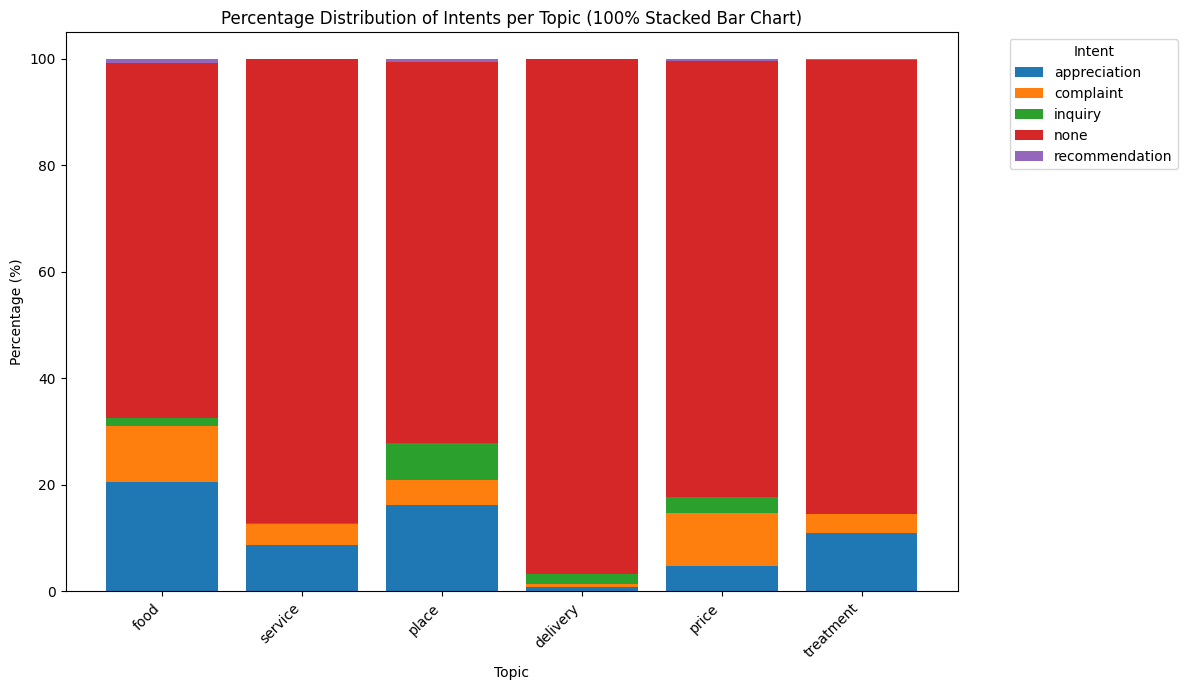

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Initialize a dictionary to store single intent counts per topic
single_intent_counts = {topic: {intent: 0 for intent in INTENTS} for topic in TOPICS}

# Iterate through the cleaned DataFrame
for idx, row in df_clean.iterrows():
    for topic in TOPICS:
        intents_str = row.get(topic, "")
        if not isinstance(intents_str, str) or intents_str.strip() == "":
            continue
        # Split multi-intent strings
        current_intents = [i.strip() for i in intents_str.split(",") if i.strip()]
        for intent in current_intents:
            if intent in single_intent_counts[topic]:
                single_intent_counts[topic][intent] += 1

# Convert to DataFrame
single_counts_df = pd.DataFrame(single_intent_counts)

# Calculate percentages per topic
single_percent_df = single_counts_df.div(single_counts_df.sum(axis=0), axis=1) * 100
single_percent_df = single_percent_df.fillna(0)

# Plot 100% stacked bar chart
plt.figure(figsize=(12, 7))
bottom = np.zeros(len(TOPICS))

# Sort intents for consistent order
sorted_intents = sorted(single_percent_df.index)

# Define a color palette
palette = sns.color_palette("tab10", n_colors=len(sorted_intents))
color_map = {intent: palette[i] for i, intent in enumerate(sorted_intents)}

for intent in sorted_intents:
    plt.bar(
        single_percent_df.columns,
        single_percent_df.loc[intent],
        bottom=bottom,
        label=intent,
        color=color_map.get(intent, 'gray')
    )
    bottom += single_percent_df.loc[intent].values

plt.title('Percentage Distribution of Intents per Topic (100% Stacked Bar Chart)')
plt.xlabel('Topic')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Intent', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
print(f" set size: {len(df)}")

if 'out_of_scope' in df.columns:
    out_of_scope_comments = df[df['out_of_scope'] == True]
    count = len(out_of_scope_comments)
    print(f"Number of comments where 'out_of_scope' is True: {count}")
else:
    print("The column 'out_of_scope' was not found in the DataFrame.")
    print("Available columns are:", df.columns.tolist())

 set size: 23928
Number of comments where 'out_of_scope' is True: 9108


In [ ]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

print(f"Training set size: {len(df_train)}")
print(f"Testing set size: {len(df_test)}")

Training set size: 19142
Testing set size: 4786


In [ ]:
class ABSADataset(Dataset):
    def __init__(self, df, tokenizer):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        text = row["comment_text"]

        # 🔒 Sécurisation ABSOLUE
        if not isinstance(text, str):
            text = ""

        inputs = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN
        )

        # Multi-label intents
        labels = torch.zeros(len(TOPICS), len(INTENTS), dtype=torch.float)

        for i, topic in enumerate(TOPICS):
            intents_str = row.get(topic, "")

            if not isinstance(intents_str, str):
                continue

            current_intents = [
                intent.strip()
                for intent in intents_str.split(",")
                if intent.strip()
            ]

            for intent in current_intents:
                if intent in INTENT2ID:
                    labels[i, INTENT2ID[intent]] = 1.0

        return {
            "input_ids": torch.tensor(inputs["input_ids"]),
            "attention_mask": torch.tensor(inputs["attention_mask"]),
            "labels": labels
        }


In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel

class DziribertABSA(nn.Module):
    """
    Une tête (Linear) séparée pour chaque topic.
    """
    def __init__(self, model_name, num_topics, num_intents):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size

        # Une tête par topic
        self.topic_classifiers = nn.ModuleList([
            nn.Linear(hidden_size, num_intents) for _ in range(num_topics)
        ])

        self.num_topics = num_topics
        self.num_intents = num_intents
        self.loss_fct = nn.BCEWithLogitsLoss()

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state[:, 0]  # [CLS]

        # Logits par topic
        topic_logits = []
        for classifier in self.topic_classifiers:
            topic_logits.append(classifier(pooled))  # (batch, num_intents)

        logits = torch.stack(topic_logits, dim=1)  # (batch, num_topics, num_intents)

        loss = None
        if labels is not None:
            loss = self.loss_fct(logits, labels.float())

        return {"loss": loss, "logits": logits}


In [ ]:
# ===== Tokenizer et Dataset =====
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
dataset = ABSADataset(df, tokenizer)

# ===== Model =====
model = DziribertABSA(MODEL_NAME, num_topics=len(TOPICS), num_intents=len(INTENTS))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/620 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertModel were not initialized from the model checkpoint at alger-ia/dziribert and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DziribertABSA(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise

In [ ]:
train_dataset = ABSADataset(df_train, tokenizer)
eval_dataset = ABSADataset(df_test, tokenizer)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Evaluation dataset size: {len(eval_dataset)}")

Training dataset size: 19142
Evaluation dataset size: 4786


In [ ]:
def collate_fn(batch):
    input_ids = torch.stack([x["input_ids"] for x in batch])
    attention_mask = torch.stack([x["attention_mask"] for x in batch])
    labels = torch.stack([x["labels"] for x in batch])
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from scipy.special import expit # For sigmoid

In [ ]:
from scipy.special import expit
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

NONE_ID = INTENT2ID["none"]

def compute_metrics(p):
    logits = p.predictions
    labels = p.label_ids

    probs = expit(logits)
    preds = (probs > 0.5).astype(int)

    metrics = {}

    num_topics = len(TOPICS)
    num_intents = len(INTENTS)

    f1_topics = []

    for t, topic in enumerate(TOPICS):
        y_true = labels[:, t, :]
        y_pred = preds[:, t, :]

        # 🔥 exclure "none"
        mask = np.ones(num_intents, dtype=bool)
        mask[NONE_ID] = False

        y_true = y_true[:, mask]
        y_pred = y_pred[:, mask]

        f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
        precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
        recall = recall_score(y_true, y_pred, average="macro", zero_division=0)

        metrics[f"{topic}_f1_macro"] = f1
        metrics[f"{topic}_precision_macro"] = precision
        metrics[f"{topic}_recall_macro"] = recall

        f1_topics.append(f1)

    # 🔥 MÉTRIQUE PRINCIPALE
    metrics["overall_f1_macro_topic"] = float(np.mean(f1_topics))

    return metrics


In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,

    metric_for_best_model="overall_f1_macro_topic",
    greater_is_better=True,

    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=collate_fn,
    compute_metrics=compute_metrics # Add the compute_metrics function here
)

In [ ]:
# ===== Entraînement =====
trainer.train()

Epoch,Training Loss,Validation Loss,Food F1 Macro,Food Precision Macro,Food Recall Macro,Service F1 Macro,Service Precision Macro,Service Recall Macro,Place F1 Macro,Place Precision Macro,Place Recall Macro,Delivery F1 Macro,Delivery Precision Macro,Delivery Recall Macro,Price F1 Macro,Price Precision Macro,Price Recall Macro,Treatment F1 Macro,Treatment Precision Macro,Treatment Recall Macro,Overall F1 Macro Topic
1,0.109100,0.099615,0.453466,0.525556,0.401198,0.335088,0.359738,0.314824,0.385866,0.627077,0.349709,0.220670,0.232353,0.210106,0.498816,0.596574,0.437242,0.303070,0.383078,0.253731,0.366163
2,0.077900,0.099472,0.475419,0.544685,0.421885,0.314632,0.383002,0.272651,0.462201,0.508532,0.441778,0.284003,0.493151,0.230496,0.521500,0.615510,0.456935,0.337786,0.386316,0.300753,0.399257
3,0.051700,0.109162,0.522135,0.574945,0.479669,0.330915,0.371050,0.301399,0.484240,0.572326,0.442072,0.332985,0.600275,0.286537,0.539973,0.550195,0.530178,0.348357,0.366034,0.334258,0.426434
4,0.027600,0.121285,0.508775,0.524283,0.497525,0.337229,0.365875,0.313087,0.532371,0.566965,0.518036,0.343091,0.399980,0.310347,0.567370,0.606394,0.540575,0.349658,0.370146,0.331691,0.439749
5,0.018400,0.129952,0.525920,0.584857,0.491736,0.332883,0.351713,0.316241,0.520410,0.552075,0.497683,0.329969,0.388492,0.298442,0.567086,0.595095,0.549593,0.412222,0.431246,0.396469,0.448082


TrainOutput(global_step=11965, training_loss=0.06052702853134672, metrics={'train_runtime': 2459.0443, 'train_samples_per_second': 38.922, 'train_steps_per_second': 4.866, 'total_flos': 0.0, 'train_loss': 0.06052702853134672, 'epoch': 5.0})

In [ ]:
print("\n--- Evaluation Results ---")
eval_results = trainer.evaluate()

# Print formatted evaluation results
for key, value in eval_results.items():
    print(f"{key}: {value:.4f}")


--- Evaluation Results ---


eval_loss: 0.1300
eval_food_f1_macro: 0.5259
eval_food_precision_macro: 0.5849
eval_food_recall_macro: 0.4917
eval_service_f1_macro: 0.3329
eval_service_precision_macro: 0.3517
eval_service_recall_macro: 0.3162
eval_place_f1_macro: 0.5204
eval_place_precision_macro: 0.5521
eval_place_recall_macro: 0.4977
eval_delivery_f1_macro: 0.3300
eval_delivery_precision_macro: 0.3885
eval_delivery_recall_macro: 0.2984
eval_price_f1_macro: 0.5671
eval_price_precision_macro: 0.5951
eval_price_recall_macro: 0.5496
eval_treatment_f1_macro: 0.4122
eval_treatment_precision_macro: 0.4312
eval_treatment_recall_macro: 0.3965
eval_overall_f1_macro_topic: 0.4481
eval_runtime: 33.2480
eval_samples_per_second: 143.9480
eval_steps_per_second: 18.0160
epoch: 5.0000


In [ ]:
# ===== Test rapide =====
def predict(comment):
    model.eval()
    inputs = tokenizer(comment, truncation=True, padding="max_length", max_length=MAX_LEN, return_tensors="pt")
    inputs = {k:v.to(device) for k,v in inputs.items() if k in ["input_ids","attention_mask"]}
    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs["logits"] # (1, num_topics, num_intents)

    # Apply sigmoid to logits to get probabilities
    probabilities = torch.sigmoid(logits) # (1, num_topics, num_intents)

    # Threshold probabilities to get binary predictions (multi-hot)
    predictions = (probabilities > 0.5).squeeze(0) # (num_topics, num_intents)

    result = {}
    for i, topic in enumerate(TOPICS):
        predicted_intents_for_topic = []
        for j in range(len(INTENTS)):
            if predictions[i, j].item() == 1:
                predicted_intents_for_topic.append(ID2INTENT[j])

        # If no intent is predicted, default to ['none'] for consistency if 'none' is a valid intent
        if not predicted_intents_for_topic:
            predicted_intents_for_topic.append("none")
        result[topic] = predicted_intents_for_topic
    return result

In [ ]:
print(predict("na9so f la musique"))


{'food': ['none'], 'service': ['none'], 'place': ['complaint'], 'delivery': ['none'], 'price': ['none'], 'treatment': ['none']}


In [ ]:
print(predict("ch3l prix, ambiance hayla, serveur mechant, win jay"))


{'food': ['none'], 'service': ['none'], 'place': ['appreciation'], 'delivery': ['none'], 'price': ['none'], 'treatment': ['none']}


In [ ]:
# model est ton instance de DziribertABSA
torch.save(model.state_dict(), "dziribert_absa.pt")
